# Model Evaluation & Hyperparameter Tuning

Model evaluation is the process of quantifying how well a model performs on unseen data. Proper evaluation prevents **data leakage** and **overfitting to the test set**.

---

## 1. Data Splitting Strategies

### Hold-out Split
Simple train/validation/test split. Risk: high variance depending on split.

### k-Fold Cross-Validation
Split data into $k$ folds. Train on $k-1$, validate on remaining. Repeat $k$ times.

$$\text{CV Score} = \frac{1}{k}\sum_{i=1}^k \text{score}_i$$

### Stratified k-Fold
Preserves class distribution in each fold. Critical for imbalanced datasets.

### Leave-One-Out (LOO)
Special case of k-fold where $k = n$. Unbiased but expensive.

### Nested Cross-Validation
Outer loop: model evaluation. Inner loop: hyperparameter tuning.
Prevents overfitting to the validation set.

$$\text{Performance} = \frac{1}{k_{outer}}\sum_i \text{score}(\text{BestModel}_i, \text{TestFold}_i)$$

---

## 2. Classification Metrics

### Confusion Matrix
$$\begin{pmatrix} TN & FP \\ FN & TP \end{pmatrix}$$

### Core Metrics
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{(of predicted positive, how many are actually positive)}$$

$$\text{Recall (Sensitivity)} = \frac{TP}{TP + FN} \quad \text{(of actual positive, how many did we catch)}$$

$$\text{Specificity} = \frac{TN}{TN + FP}$$

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}$$

$$F_\beta = (1+\beta^2)\frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

$\beta > 1$: weight recall more. $\beta < 1$: weight precision more.

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

$$\text{Log Loss} = -\frac{1}{N}\sum_{i=1}^N [y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)]$$

CLASSIFICATION METRICS
Accuracy:          0.9150
Precision:         0.9231
Recall:            0.7869
F1 Score:          0.8496
ROC-AUC:           0.9728
PR-AUC:            0.9465
MCC:               0.7957
Cohen's Kappa:     0.7908
Log Loss:          0.2067
Brier Score:       0.0614

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       139
           1       0.92      0.79      0.85        61

    accuracy                           0.92       200
   macro avg       0.92      0.88      0.90       200
weighted avg       0.92      0.92      0.91       200



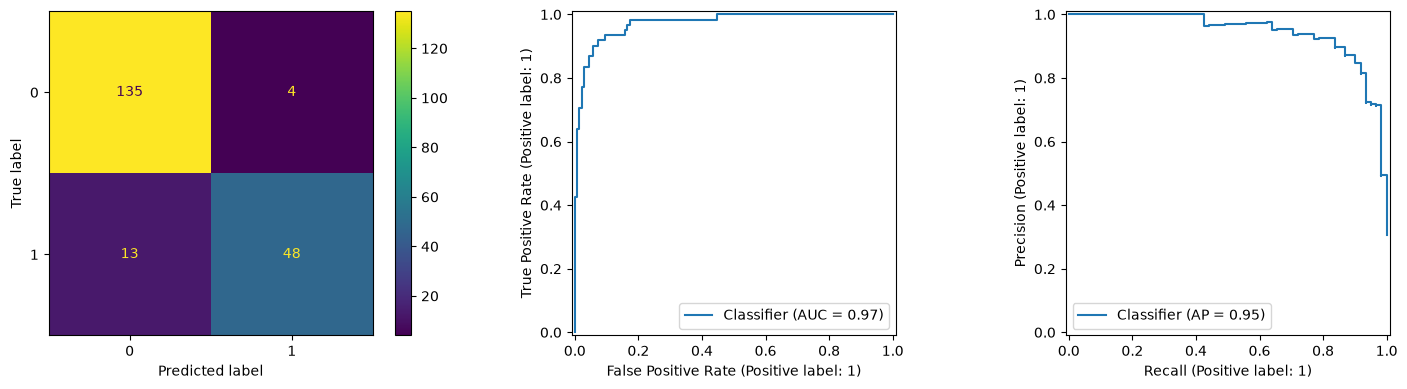

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut,
    RepeatedStratifiedKFold, cross_val_score, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, matthews_corrcoef, cohen_kappa_score,
    brier_score_loss, log_loss, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import warnings; warnings.filterwarnings('ignore')

# Dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                            weights=[0.7, 0.3], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CLASSIFICATION METRICS")
print("=" * 50)
print(f"Accuracy:          {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:         {precision_score(y_test, y_pred):.4f}")
print(f"Recall:            {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:          {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:            {average_precision_score(y_test, y_prob):.4f}")
print(f"MCC:               {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"Cohen's Kappa:     {cohen_kappa_score(y_test, y_pred):.4f}")
print(f"Log Loss:          {log_loss(y_test, y_prob):.4f}")
print(f"Brier Score:       {brier_score_loss(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
plt.tight_layout(); plt.show()

---

## 3. Regression Metrics

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$$

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

$$\text{MAPE} = \frac{100}{n}\sum_{i=1}^n \left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

$$\text{SMAPE} = \frac{100}{n}\sum_{i=1}^n \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2}$$

$$R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

$$R^2_{adj} = 1 - (1-R^2)\frac{n-1}{n-p-1}$$

where $p$ = number of features, $n$ = number of samples.

---

## 4. Hyperparameter Tuning

In [2]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats

# Regression metrics
X_reg, y_reg = make_regression(n_samples=500, n_features=10, noise=20, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

from sklearn.ensemble import GradientBoostingRegressor
reg = GradientBoostingRegressor(random_state=42).fit(X_tr, y_tr)
y_pred_r = reg.predict(X_te)

print("REGRESSION METRICS")
print(f"MAE:  {mean_absolute_error(y_te, y_pred_r):.4f}")
print(f"MSE:  {mean_squared_error(y_te, y_pred_r):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_te, y_pred_r)):.4f}")
print(f"R²:   {r2_score(y_te, y_pred_r):.4f}")
n, p = X_te.shape
r2 = r2_score(y_te, y_pred_r)
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
print(f"Adj R²: {adj_r2:.4f}")

# GridSearchCV
param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid,
                            cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
print(f"\nGridSearch best params: {grid_search.best_params_}")
print(f"GridSearch best CV AUC: {grid_search.best_score_:.4f}")

# RandomizedSearchCV
param_dist = {
    'n_estimators': stats.randint(50, 300),
    'max_depth': stats.randint(2, 8),
    'learning_rate': stats.uniform(0.01, 0.3),
    'subsample': stats.uniform(0.6, 0.4)
}
rand_search = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), param_dist,
                                  n_iter=20, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)
rand_search.fit(X_train, y_train)
print(f"RandomSearch best params: {rand_search.best_params_}")
print(f"RandomSearch best CV AUC: {rand_search.best_score_:.4f}")

REGRESSION METRICS
MAE:  40.9035
MSE:  2735.3643
RMSE: 52.3007
R²:   0.8620
Adj R²: 0.8465



GridSearch best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
GridSearch best CV AUC: 0.9663


RandomSearch best params: {'learning_rate': np.float64(0.28279612062363463), 'max_depth': 5, 'n_estimators': 99, 'subsample': np.float64(0.8650089137415928)}
RandomSearch best CV AUC: 0.9716


In [3]:
# Bayesian Optimization with Optuna
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 2, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        }
        clf = GradientBoostingClassifier(**params, random_state=42)
        score = cross_val_score(clf, X_train, y_train, cv=3, scoring='roc_auc').mean()
        return score
    
    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=30, timeout=60)
    print(f"Optuna best AUC: {study.best_value:.4f}")
    print(f"Optuna best params: {study.best_params}")
except ImportError:
    print("Install Optuna: pip install optuna")

# Cross-validation comparison
cv_strategies = {
    'KFold-5': KFold(n_splits=5, shuffle=True, random_state=42),
    'StratifiedKFold-5': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'RepeatedStratified': RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
}
print("\nCross-validation strategy comparison:")
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
for name, cv in cv_strategies.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    print(f"  {name}: {scores.mean():.4f} ± {scores.std():.4f}")

Optuna best AUC: 0.9724
Optuna best params: {'n_estimators': 120, 'max_depth': 8, 'learning_rate': 0.13924613533466104, 'subsample': 0.7727949000590059, 'min_samples_split': 17}

Cross-validation strategy comparison:


  KFold-5: 0.9732 ± 0.0066


  StratifiedKFold-5: 0.9754 ± 0.0101


  RepeatedStratified: 0.9734 ± 0.0106


---

## 5. Calibration

A well-calibrated model: if it predicts 70% probability for a class, ~70% of such samples should actually be that class.

$$\text{ECE} = \sum_{b=1}^B \frac{|B_b|}{n}|\text{acc}(B_b) - \text{conf}(B_b)|$$

Methods: **Platt Scaling** (sigmoid on scores), **Isotonic Regression** (non-parametric).

---

## Additional Learning Resources

### Documentation
- **scikit-learn Model Evaluation**: [https://scikit-learn.org/stable/modules/model_evaluation.html](https://scikit-learn.org/stable/modules/model_evaluation.html)
- **Optuna**: [https://optuna.readthedocs.io/](https://optuna.readthedocs.io/)

### Papers
- **Hyperband**: [https://arxiv.org/abs/1603.06212](https://arxiv.org/abs/1603.06212)
- **Bayesian Optimization Tutorial**: [https://arxiv.org/abs/1012.2599](https://arxiv.org/abs/1012.2599)

### Books
- **Evaluating Machine Learning Models** (O'Reilly): [https://www.oreilly.com/library/view/evaluating-machine-learning/9781492048756/](https://www.oreilly.com/library/view/evaluating-machine-learning/9781492048756/)

### Courses
- **Kaggle: Intermediate Machine Learning**: [https://www.kaggle.com/learn/intermediate-machine-learning](https://www.kaggle.com/learn/intermediate-machine-learning)